<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Analizando el Delito en Chicago

En este caso-taller vamos a utilizar datos geográficos y estimación de densidad de kernel para analizar delitos en Chicago. Esta ciudad es muy famosa no sólo por haber sido el hogar del mafioso Al Capone, sino también por sus altas tasas de delitos. 

Para este taller obtuve datos del portal de la [ciudad de Chicago](https://www.chicago.gov/city/en/dataset/crime.html). La base de datos fue traducida y modificada para nuestras necesidades. Esta contiene todos los homicidios y robos que sucedieron entre el 1 de junio y el 31 de agosto de 2019.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Librerias

In [231]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from pyrosm import OSM, get_data
from IPython.display import IFrame
from geopy.distance import geodesic
from shapely.ops import nearest_points
import folium
import scipy.stats
import sklearn.model_selection
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy import stats
from bokeh.plotting import figure, output_notebook, show
import xyzservices.providers as xyz
import statsmodels.api as sm
import geojsoncontour
from sklearn.datasets import make_blobs
from geopy.distance import geodesic
from statsmodels.nonparametric.api import KDEMultivariate
import plotly.graph_objects as go

## Desarrollo


### 1.Carga de datos 

#### 1.1. Delitos

En la carpeta `data` se encuentra el archivo `Chicago_delitos_verano_2019.csv` cargue estos datos en su *cuaderno*. Describa brevemente el contenido de la base.

In [28]:
# Utilice este espacio para escribir el código.
path = 'data/Chicago_delitos_verano_2019.csv'
df = pd.read_csv(path)
df.head()

,fecha,tipo_crimen,nro_area_comunitaria,lat,lon
0,2019-06-01T05:07:00Z,homicidio,23,41.897950,-87.728625
1,2019-06-01T10:09:00Z,homicidio,71,41.753272,-87.648963
2,2019-06-01T12:46:00Z,homicidio,25,41.877622,-87.750728
3,2019-06-01T11:35:00Z,homicidio,16,41.960145,-87.699654
4,2019-06-02T09:39:00Z,homicidio,37,41.804773,-87.633256


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17747 entries, 0 to 17746
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 17747 non-null  object 
 1   tipo_crimen           17747 non-null  object 
 2   nro_area_comunitaria  17747 non-null  int64  
 3   lat                   17747 non-null  float64
 4   lon                   17747 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 693.4+ KB


(Utilice este espacio para describir su procedimiento)

#### 1.2. Barrios de Chicago

También en la carpeta `data` se encuentran los archivos con los polígonos de las áreas comunitarias en un archivo comprimido llamado `Areas_comunitarias_Chicago.zip`. Genere un mapa interactivo con un popup con el nombre del area comunitaria.

In [35]:
# Utilice este espacio para escribir el código.
gdf = gpd.read_file("data/Areas_comunitarias_Chicago.zip")

gdf.head()

,area,area_num_1,area_numbe,comarea,comarea_id,community,perimeter,shape_area,shape_len,geometry
0,0.0,35,35,0.0,0.0,DOUGLAS,0.0,4.600462e+07,31027.054510,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,0.0,36,36,0.0,0.0,OAKLAND,0.0,1.691396e+07,19565.506153,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,0.0,37,37,0.0,0.0,FULLER PARK,0.0,1.991670e+07,25339.089750,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,0.0,38,38,0.0,0.0,GRAND BOULEVARD,0.0,4.849250e+07,28196.837157,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,0.0,39,39,0.0,0.0,KENWOOD,0.0,2.907174e+07,23325.167906,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


In [41]:
m = folium.Map(location=[41.8781, -87.6298], zoom_start=10)

folium.GeoJson(
    gdf,
    name="Comunidades",
    tooltip=folium.GeoJsonTooltip(fields=["community"], aliases=["Comunidad:"]),
    popup=folium.GeoJsonPopup(fields=["community"])
).add_to(m)

In [43]:
m

(Utilice este espacio para describir su procedimiento).

### 2.   Análisis distribución del crimen por barrios

#### 2.1.  Genere una tabla descriptiva donde se muestra el número total de delitos, el número total de robos y el número total de homicidios, y como porcentaje de total por barrios. La tabla debe contener ademas una fila final donde se muestre el total para la ciudad. Describa los resultados que obtiene.


In [57]:
# Utilice este espacio para escribir el código.
tabla = (
    df
    .groupby("nro_area_comunitaria")
    .agg(
        total_delitos=("tipo_crimen", "count"),
        robos=("tipo_crimen", lambda x: (x == "robo").sum()),
        homicidios=("tipo_crimen", lambda x: (x == "homicidio").sum())
    )
    .reset_index()
)

tabla["%_robos"] = 100 * tabla["robos"] / tabla["total_delitos"]
tabla["%_homicidios"] = 100 * tabla["homicidios"] / tabla["total_delitos"]

totales = pd.DataFrame([{
    "nro_area_comunitaria": "TOTAL CIUDAD",
    "total_delitos": tabla["total_delitos"].sum(),
    "robos": tabla["robos"].sum(),
    "homicidios": tabla["homicidios"].sum()
}])

totales["%_robos"] = 100 * totales["robos"] / totales["total_delitos"]
totales["%_homicidios"] = 100 * totales["homicidios"] / totales["total_delitos"]


tabla_final = pd.concat([tabla, totales], ignore_index=True)

tabla_final

,nro_area_comunitaria,total_delitos,robos,homicidios,%_robos,%_homicidios
0,1,377,375,2,99.469496,0.530504
1,2,280,280,0,100.000000,0.000000
2,3,266,266,0,100.000000,0.000000
3,4,169,169,0,100.000000,0.000000
4,5,99,99,0,100.000000,0.000000
...,...,...,...,...,...,...
73,74,21,21,0,100.000000,0.000000
74,75,124,124,0,100.000000,0.000000
75,76,163,163,0,100.000000,0.000000
76,77,228,228,0,100.000000,0.000000


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

#### 2.2. Genere una gráfica de dispersión entre el total de homicidios y robos por barrios. Incluya en la gráfica la recta de regresión que mejor ajusta a esos datos. Describa los resultados que obtiene.

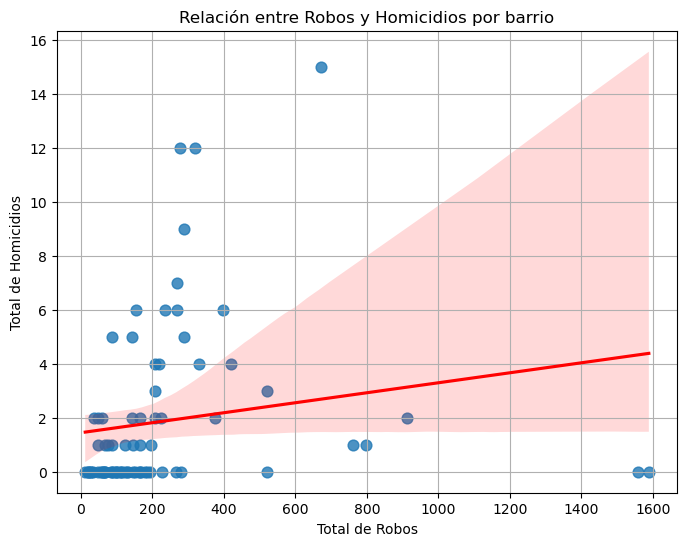

In [59]:
# Utilice este espacio para escribir el código.
df_plot = tabla[["robos", "homicidios"]]

plt.figure(figsize=(8,6))
sns.regplot(x="robos", y="homicidios", data=df_plot, scatter_kws={"s":60}, line_kws={"color":"red"})

plt.title("Relación entre Robos y Homicidios por barrio")
plt.xlabel("Total de Robos")
plt.ylabel("Total de Homicidios")
plt.grid(True)
plt.show()

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 3. Distribución espacial del delito

#### 3.1 Distribución respecto al centro de la ciudad

Tomando como centro de la ciudad las coordenadas (-87.627800, 41.881998), estime funciones de densidad que muestren gráficamente el gradiente del total de robos, y homicidios, como función de la distancia al centro de la ciudad. Explique cómo midió las distancias incluyendo que medida de distancia utilizó. Para elegir el ancho de banda y la función de kernel más apropiados utilice validación cruzada usando todas las opciones posibles de kernel. Describa los resultados que obtiene.

In [131]:
folium.Marker(
      location=[PB.iloc[0]['Latitud'], PB.iloc[0]['Longitud']]
).add_to(m)

In [183]:
PB = pd.DataFrame({
    "lugar": ["Centro Chicago"],
    "Latitud": [41.881998],
    "Longitud": [-87.627800]
    })

geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf_crimes = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs="EPSG:4326")

PB = gpd.GeoDataFrame(PB, geometry = gpd.points_from_xy(PB.Longitud, PB.Latitud, crs='EPSG:4326'))

centro_coords = (PB.iloc[0].Latitud, PB.iloc[0].Longitud)
gdf_crimes["distancias"] = gdf_crimes.geometry.apply(lambda p: geodesic(centro_coords, (p.y, p.x)).m)

In [185]:
gdf_crimes.head()

,fecha,tipo_crimen,nro_area_comunitaria,lat,lon,distancias,geometry
0,2019-06-01T05:07:00Z,homicidio,23,41.897950,-87.728625,8553.360871,POINT (-87.72863 41.89795)
1,2019-06-01T10:09:00Z,homicidio,71,41.753272,-87.648963,14405.274740,POINT (-87.64896 41.75327)
2,2019-06-01T12:46:00Z,homicidio,25,41.877622,-87.750728,10215.363930,POINT (-87.75073 41.87762)
3,2019-06-01T11:35:00Z,homicidio,16,41.960145,-87.699654,10529.419290,POINT (-87.69965 41.96015)
4,2019-06-02T09:39:00Z,homicidio,37,41.804773,-87.633256,8589.378650,POINT (-87.63326 41.80477)


In [187]:
gdf_crimes['distancias'].describe()

count    17747.000000
mean      9017.958461
std       5992.482189
min         23.620891
25%       3891.876710
50%       8674.171718
75%      13384.658303
max      27285.786091
Name: distancias, dtype: float64

In [189]:
gdf_crimes.loc[gdf_crimes['tipo_crimen']=='robo','distancias'].describe()

count    17603.000000
mean      8997.990456
std       5999.845971
min         23.620891
25%       3850.411097
50%       8638.871029
75%      13384.083076
max      27285.786091
Name: distancias, dtype: float64

In [191]:
gdf_crimes.loc[gdf_crimes['tipo_crimen']=='homicidio','distancias'].describe()

count      144.000000
mean     11458.908448
std       4386.565093
min       3060.513519
25%       7933.632615
50%      10721.769709
75%      14331.459523
max      22659.096229
Name: distancias, dtype: float64

In [221]:
X_robo = gdf_crimes.loc[gdf_crimes['tipo_crimen']=='robo','distancias'].values[:, None]

params_robo = {
    "bandwidth": np.linspace(8, 12, 17),
    "kernel": ["gaussian", "epanechnikov", "tophat", "linear"]
}

grid_robo = GridSearchCV(KernelDensity(), params_robo, cv=5)
grid_robo.fit(X_robo)

print("Mejores parámetros encontrados para robos:")
print(grid_robo.best_params_)

# Modelo KDE óptimo
best_kde_robo = grid_robo.best_estimator_

Mejores parámetros encontrados para robos:
{'bandwidth': 10.75, 'kernel': 'gaussian'}


C:\Users\danie\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-34818.21662575            -inf            -inf            -inf
 -34813.71526941            -inf            -inf            -inf
 -34809.94731249            -inf            -inf            -inf
 -34806.81642655            -inf            -inf            -inf
 -34804.24060077            -inf            -inf            -inf
 -34802.1497385             -inf            -inf            -inf
 -34800.48369842            -inf            -inf            -inf
 -34799.19068777            -inf            -inf            -inf
 -34798.22593916            -inf            -inf            -inf
 -34797.55061772            -inf            -inf            -inf
 -34797.13091649            -inf            -inf            -inf
 -34796.93730594            -inf            -inf            -inf
 -34796.94391007            -inf            -inf            -inf
 -34797.127

In [222]:
X_homi = gdf_crimes.loc[gdf_crimes['tipo_crimen']=='homicidio','distancias'].values[:, None]

params_homi = {
    "bandwidth": np.linspace(2000, 2500, 400),
    "kernel": ["gaussian", "epanechnikov", "tophat", "linear"]
}

grid_homi = GridSearchCV(KernelDensity(), params_homi, cv=5)
grid_homi.fit(X_homi)

print("Mejores parámetros encontrados para homicidios:")
print(grid_homi.best_params_)

# Modelo KDE óptimo
best_kde_homi = grid_homi.best_estimator_

Mejores parámetros encontrados para homicidios:
{'bandwidth': 2205.5137844611527, 'kernel': 'linear'}


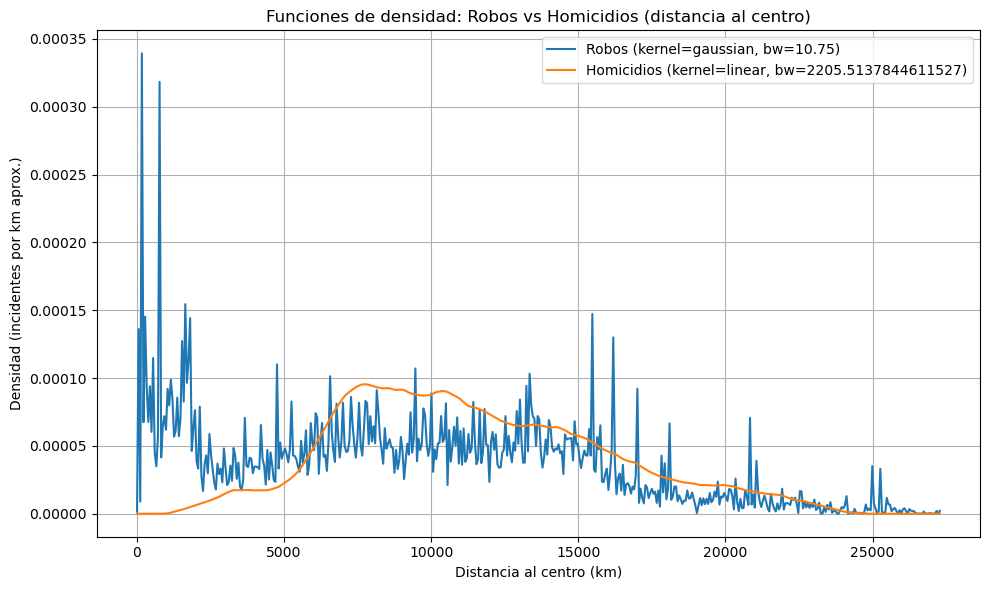

In [227]:
max_d = max(gdf_crimes['distancias'].max(), 30)
d_vals = np.linspace(0, max_d, 500)[:, None]  # forma (500,1)

# densidades (KDE devuelve log-densidad)
dens_robos = np.exp(best_kde_robo.score_samples(d_vals))
dens_hom = np.exp(best_kde_homi.score_samples(d_vals))

plt.figure(figsize=(10,6))
plt.plot(
    d_vals.flatten(),
    dens_robos,
    label=f"Robos (kernel={best_kde_robo.kernel}, bw={best_kde_robo.bandwidth})"
)
plt.plot(
    d_vals.flatten(),
    dens_hom,
    label=f"Homicidios (kernel={best_kde_homi.kernel}, bw={best_kde_homi.bandwidth})"
)

plt.xlabel("Distancia al centro (km)")
plt.ylabel("Densidad (incidentes por km aprox.)")
plt.title("Funciones de densidad: Robos vs Homicidios (distancia al centro)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 3.2 Puntos calientes en la ciudad

Usando `statsmodels` implemente la estimación de densidad bivariada para el total de robos y el total de homicidios. Muestre los resultados usando curvas de nivel en una visualización interactiva. Compare los resultados de estimar usando los anchos de banda: `normal_reference` y `cv_ml`. Explique en que consisten ambas formas de estimar el ancho de banda. Comente sobre los puntos calientes encontrados bajo ambos métodos y su ubicación en la ciudad. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

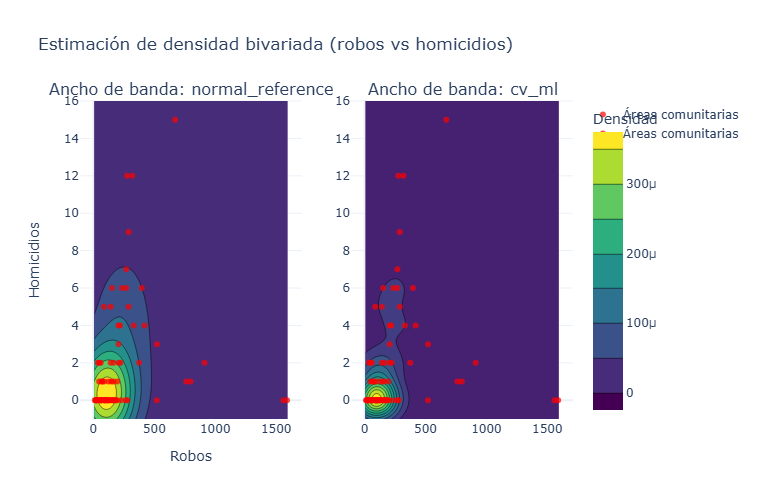

In [247]:
# Utilice este espacio para escribir el código.

X = tabla_final.loc[tabla_final["nro_area_comunitaria"]!="TOTAL CIUDAD", ["robos","homicidios"]].values

kde_normal = sm.nonparametric.KDEMultivariate(data=X, var_type='cc', bw='normal_reference')
kde_cv = sm.nonparametric.KDEMultivariate(data=X, var_type='cc', bw='cv_ml')

x = np.linspace(X[:,0].min() - 5, X[:,0].max() + 5, 200)  
y = np.linspace(X[:,1].min() - 1, X[:,1].max() + 1, 200) 
xx, yy = np.meshgrid(x, y)
grid = np.column_stack((xx.flatten(), yy.flatten()))

dens_normal = kde_normal.pdf(data_predict=grid).reshape(xx.shape)
dens_cv = kde_cv.pdf(data_predict=grid).reshape(xx.shape)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Ancho de banda: normal_reference", "Ancho de banda: cv_ml"),
    horizontal_spacing=0.1
)

fig.add_trace(go.Contour(
    x=x, y=y, z=dens_normal,
    colorscale="Viridis",
    contours=dict(showlines=True, coloring="fill"),
    colorbar=dict(title="Densidad"),
    name="KDE normal_reference"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode="markers",
    marker=dict(size=6, color="red", opacity=0.7),
    name="Áreas comunitarias"
), row=1, col=1)

fig.add_trace(go.Contour(
    x=x, y=y, z=dens_cv,
    colorscale="Viridis",
    contours=dict(showlines=True, coloring="fill"),
    colorbar=dict(title="Densidad"),
    name="KDE cv_ml",
    showscale=False  
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode="markers",
    marker=dict(size=6, color="red", opacity=0.7),
    name="Áreas comunitarias"
), row=1, col=2)

fig.update_layout(
    title="Estimación de densidad bivariada (robos vs homicidios)",
    xaxis_title="Robos",
    yaxis_title="Homicidios",
    template="plotly_white",
    width=1000, height=500
)

fig.show()

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

## 4. Explicando la ubicación del delito

El objetivo de este punto es encontrar posibles correlaciones  entre el crimen y características de la ciudad. Para ello, utilice los datos de OpenStreetMap y explore si existe una correlación entre el porcentaje del área de la comunidad  dedicado a tiendas (`retail`)  y comercios (`commercial`) y el número total de robos y homicidios en esa comunidad. Ofrezca una explicación intuitiva de por qué cree que aparecen estas correlaciones. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)